# Example of autoscaling problem

In [9]:
# Basic imports
from ascal import AscalConfig, Ascal
from examples import aws_eu_west_1_c5m5r5 # A familiy of instance classes

In [10]:
# Configuration file defining ASCAL problem
config_file = "config.yaml"
log_file = "config.log" # Log file

In [11]:
# Read the problem configuration file and validate it
# Note that it is possible to validate any ASCAL configuration with method AscalConfig.validate_config()
ascal_config = AscalConfig.get_from_config_yaml(config_file, aws_eu_west_1_c5m5r5.c5_m5_r5_fm)

# Create the autoscaling problem
ascal_problem = Ascal(ascal_config, log=log_file)

# Last time that can be simulated (last time in the trace)
# Simulating time unit is seconds, so 3600 means 1 hour. Time starting from 0
last_time = ascal_problem.last_time 
print(f'Time range of the simulation: 0 - {last_time} seconds')

# Run the autoscaling problem until the end. The argument of run() method is the last simulation time in seconds
# Simulating time unit is seconds, so 3600 means 1 hour. Time starting from 0
ascal_problem.run()

Time range of the simulation: 0 - 3599 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
Time: 500 s
You can check the CBC log at /tmp/bd242a7bd2fb45fd80cc9c4cde970cec-pulp.lp.log
You can check the CBC log at /tmp/094d15be8e12498f8231c612228dc9df-pulp.lp.log
Time: 600 s
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
Time: 1100 s
You can check the CBC log at /tmp/9e87003388744d0789dcd75303918af1-pulp.lp.log
You can check the CBC log at /tmp/c75bf60f5f8d4dc1afcde14a4c0f6609-pulp.lp.log
Time: 1200 s
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
Time: 1700 s
Time: 1800 s
You can check the CBC log at /tmp/6b016358bd4a4b5394ab4523e590a0dd-pulp.lp.log
You can check the CBC log at /tmp/c223fc5a5bf74b48a948b4bb1848b406-pulp.lp.log
Time: 1900 s
Time: 2000 s
Time: 2100 s
Time: 2200 s
Time: 2300 s
Time: 2400 s
You can check the CBC log at /tmp/757bc5eaf1da416c8764b522c07f781a-pulp.lp.log
You can check the CBC log at /tmp/c201f685559a48eb8f069310c7197da6-pulp.lp.log
Time: 25

In [12]:
# Write workloads, performance and cost into csv files. Each line in the csv files corresponds to 1 second
ascal_problem.write_workload_csv('workloads.csv')
ascal_problem.write_performance_csv('performances.csv')
ascal_problem.write_cost_csv('cost.csv')

In [13]:
# Get application overloads (workload/performance)
workloads = ascal_problem.get_workloads()
performances = ascal_problem.get_performances()
overloads = {app: [w/p for w, p in zip(workloads[app], performances[app])] for app in workloads}

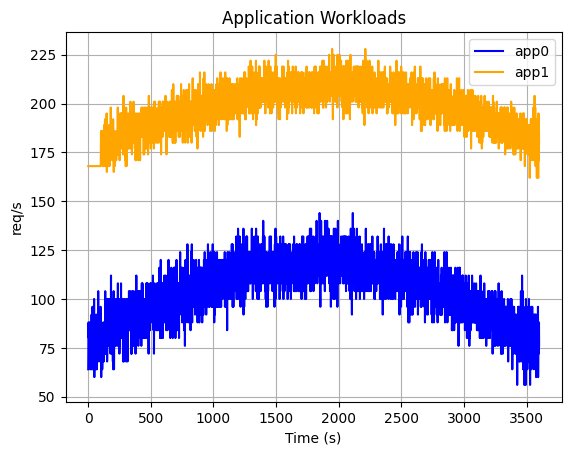

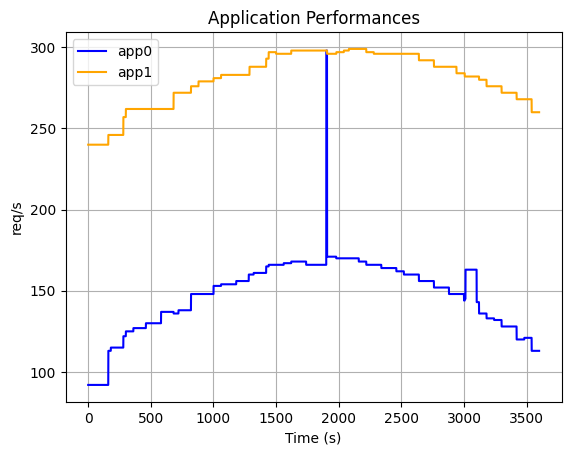

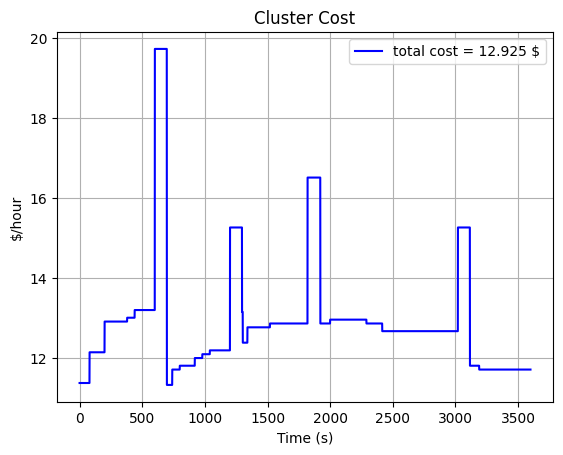

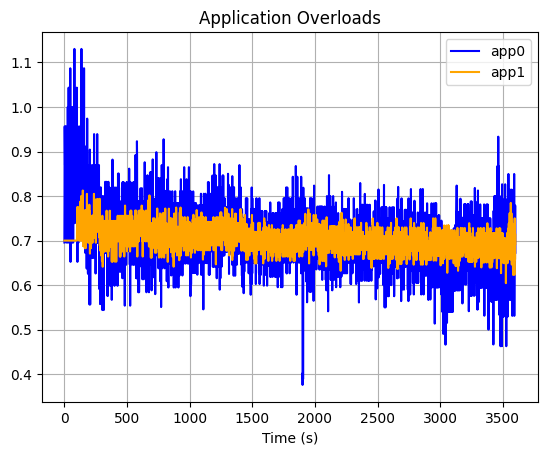

In [14]:
# Plot autoscaling information
ascal_problem.plot(ascal_problem.get_workloads(), "Application Workloads", "req/s")
ascal_problem.plot(ascal_problem.get_performances(), "Application Performances", "req/s")
cluster_cost = ascal_problem.get_cluster_cost()
total_cost_str = f"total cost = {sum(cluster_cost)/(last_time + 1):.3f} $"
ascal_problem.plot({total_cost_str: cluster_cost}, "Cluster Cost", "$/hour")
ascal_problem.plot(overloads, "Application Overloads")

In [15]:
# Useful properties
last_time = ascal_problem.last_time # Last time that can be simulated
time =  ascal_problem.time # Current simulated time in range [0, last_time]
billing_changes = ascal_problem.billing_changes # Dictionary with times and cluster state on billing changes
performance_changes = ascal_problem.performance_changes # Dictionary with times and cluster state on allocation changes
calculation_times = ascal_problem.calc_times # Calculation times used to obtain new allocations

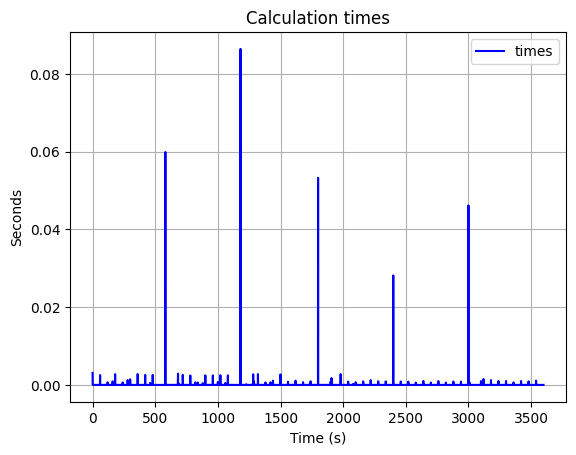

In [16]:
# Plot calculation times
ascal_problem.plot({'times': calculation_times}, "Calculation times", "Seconds")